In [1]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt  
%matplotlib inline
plt.style.use('seaborn-darkgrid')

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import warnings
warnings.filterwarnings('ignore')

In [3]:
import quantstats as qs
import yfinance as yf
import datetime as dt

In [4]:
#end_date = dt.datetime(2014,12,31).date()
#start_date = dt.datetime(2008,1,1).date()

end_date = dt.datetime(2024,3,31).date()
start_date = dt.datetime(2020,1,1).date()

print('Start date:', start_date)
print('End date:', end_date)

Start date: 2020-01-01
End date: 2024-03-31


In [5]:
def download_daily_data(ticker, start_date, end_date):
    data = yf.download(ticker, start_date, end_date)
    #data = data.replace([np.inf, -np.inf], np.nan).dropna()
    #data = data.replace([np.inf, -np.inf], np.nan).fillna(method='ffill')
    return data


In [6]:
hdfc_bank = download_daily_data('HDFCBANK.NS', start_date, end_date)

[*********************100%%**********************]  1 of 1 completed


In [7]:
kotak_bank = download_daily_data('KOTAKBANK.NS', start_date, end_date)

[*********************100%%**********************]  1 of 1 completed


In [8]:
x = hdfc_bank['Adj Close']
y = kotak_bank['Adj Close']

df = pd.concat([x,y],axis=1)
df.columns = ['Hdfc','Kotak']
df.index = pd.to_datetime(df.index, yearfirst=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [9]:
df.tail()

,Hdfc,Kotak
Date,,
2024-03-21,1426.273560,1772.150024
2024-03-22,1423.412598,1776.400024
2024-03-26,1406.197754,1753.699951
2024-03-27,1421.291626,1775.599976
2024-03-28,1428.394653,1785.500000


In [10]:
df.isnull().sum()

Hdfc     0
Kotak    0
dtype: int64

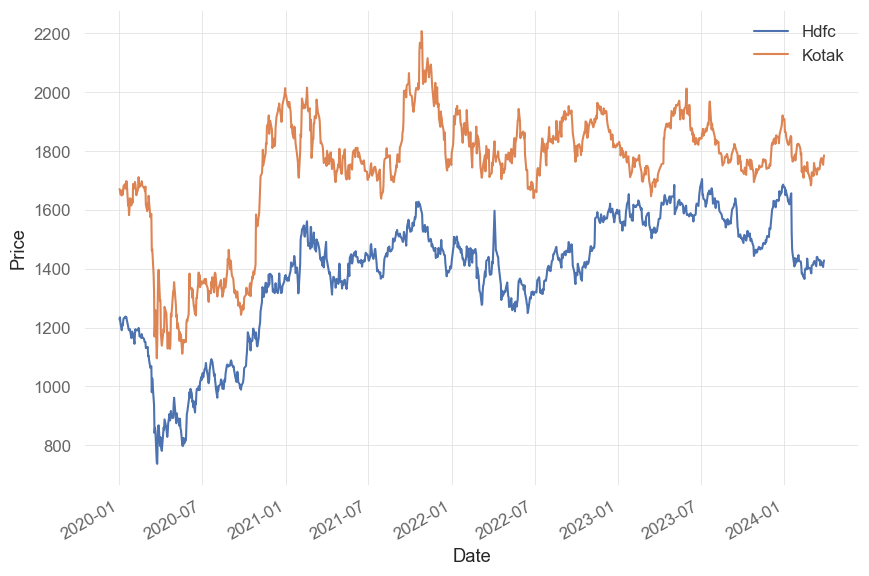

In [11]:
df.plot(figsize=(10,7))
plt.ylabel("Price")
plt.show();

In [12]:
import statsmodels.api as sm
model = sm.OLS(df.Hdfc.iloc[:90], df.Kotak.iloc[:90])
model = model.fit()

In [13]:
print('The hedge ratio is %.2f' % model.params[0])

The hedge ratio is 0.71


In [14]:
model.params[0]

0.7085487724561896

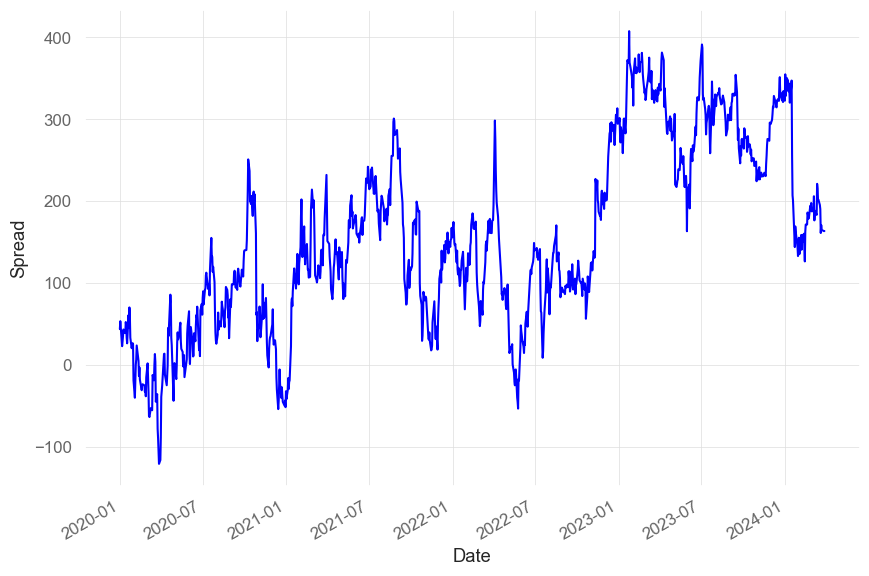

In [15]:
df['spread'] = df.Hdfc - model.params[0] * df.Kotak
# Plot the spread
df.spread.plot(figsize=(10,7), color='blue')
plt.ylabel("Spread")
plt.show();

In [16]:
# To perform ADF Test
from statsmodels.tsa.stattools import adfuller
# Compute ADF test statistics
adf = adfuller(df.spread, maxlag = 1)
round(adf[0],2)

-2.95

In [17]:
adf[4]

{'1%': -3.4365872439265366,
 '5%': -2.8642939151214337,
 '10%': -2.568236291810346}

In [18]:
def mean_reversion_strategy(df, lookback, std_dev):

    # Moving Average
    df['moving_average'] = df.spread.rolling(lookback).mean()
    # Moving Standard Deviation
    df['moving_std_dev'] = df.spread.rolling(lookback).std()

    # Upper band and lower band
    df['upper_band'] = df.moving_average + std_dev*df.moving_std_dev
    df['lower_band'] = df.moving_average - std_dev*df.moving_std_dev

    # Long positions
    df['long_entry'] = df.spread < df.lower_band
    df['long_exit'] = df.spread >= df.moving_average

    df['positions_long'] = np.nan
    df.loc[df.long_entry, 'positions_long'] = 1
    df.loc[df.long_exit, 'positions_long'] = 0
    df.positions_long = df.positions_long.fillna(method='ffill')

    # Short positions
    df['short_entry'] = df.spread > df.upper_band
    df['short_exit'] = df.spread <= df.moving_average

    df['positions_short'] = np.nan
    df.loc[df.short_entry, 'positions_short'] = -1
    df.loc[df.short_exit, 'positions_short'] = 0

    df.positions_short = df.positions_short.fillna(method='ffill')

    # Positions
    df['positions'] = df.positions_long + df.positions_short

    return df

In [19]:
df = mean_reversion_strategy(df, 60, 2)

In [20]:
df['percentage_change'] = (df.spread - df.spread.shift(1))/(model.params[0]*df.Kotak + df.Hdfc)
df['strategy_returns'] = df.positions.shift(1) * df.percentage_change
df['cumulative_returns'] = (df.strategy_returns+1).cumprod()
"The total strategy returns are %.2f" % ((df['cumulative_returns'].iloc[-1]-1)*100)

'The total strategy returns are 64.91'

In [21]:
s = np.mean(df['strategy_returns'])/np.std(df['strategy_returns'])*(252**0.5)
print("Sharpe Ratio is :", s)

Sharpe Ratio is : 1.5648620921585659


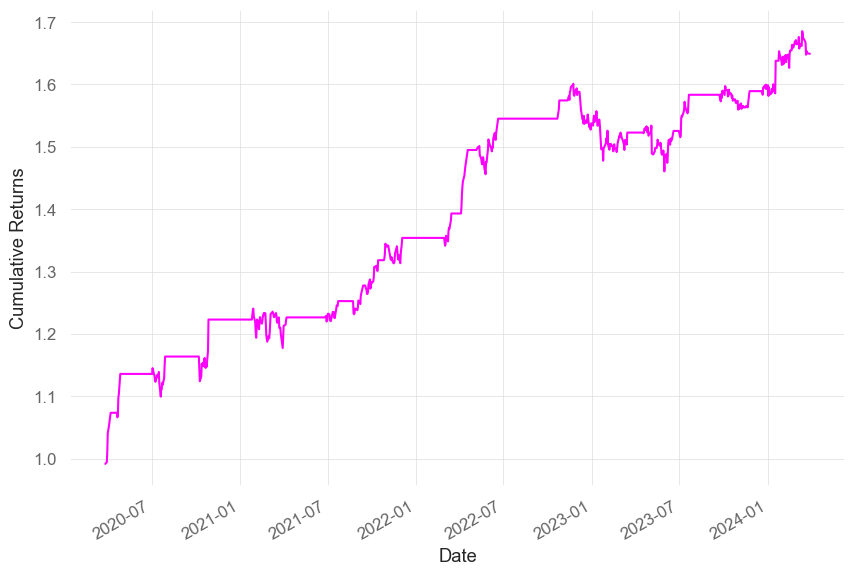

In [22]:
df.cumulative_returns.plot(label='Returns', figsize=(10,7),color='magenta')  
plt.xlabel('Date')  
plt.ylabel('Cumulative Returns')  
plt.show();

The maximum drawdown is -8.77


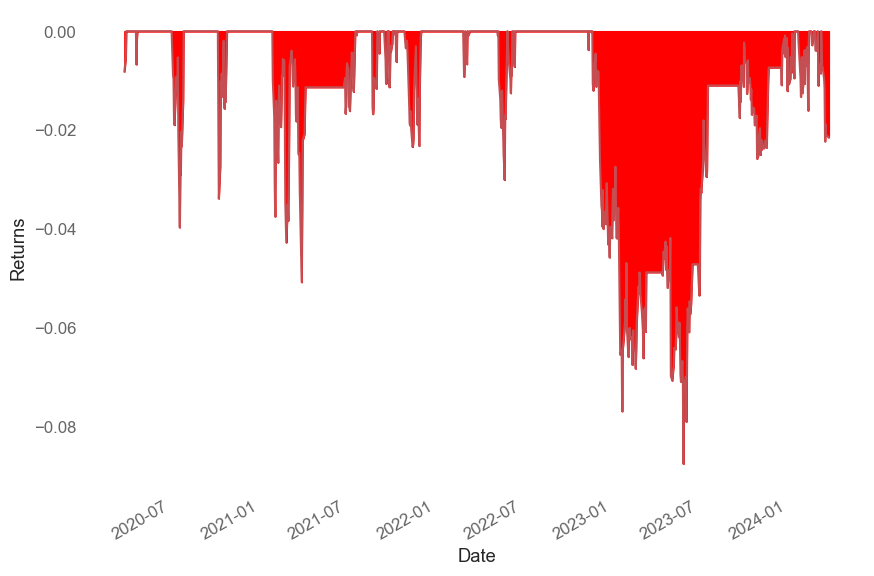

In [23]:
def calc_drawdown(cum_rets):
    # Calculate the running maximum
    running_max = np.maximum.accumulate(cum_rets.dropna())
    # Ensure the value never drops below 1
    running_max[running_max < 1] = 1
    # Calculate the percentage drawdown
    drawdown = (cum_rets)/running_max - 1
    return drawdown

def plot_drawdown(drawdown):
    fig = plt.figure(figsize=(10, 7))
    # Plot
    drawdown.plot(color='r')
    plt.ylabel('Returns')
    plt.fill_between(drawdown.index, drawdown, color='red')
    plt.grid(which="major", color='k', linestyle='-.', linewidth=0.2)
    plt.show()
    
drawdown = calc_drawdown(df.cumulative_returns)
print("The maximum drawdown is %.2f" % (drawdown.min()*100))
plot_drawdown(drawdown)

                    Strategy
------------------  ----------
Start Period        2020-03-27
End Period          2024-03-28
Risk-Free Rate      0.0%
Time in Market      48.0%

Cumulative Return   64.91%
CAGR﹪              9.01%

Sharpe              1.56
Prob. Sharpe Ratio  99.94%
Sortino             2.67
Sortino/√2          1.89
Omega               1.49

Max Drawdown        -8.77%
Longest DD Days     419

Gain/Pain Ratio     0.49
Gain/Pain (1M)      2.88

Payoff Ratio        1.33
Profit Factor       1.49
Common Sense Ratio  2.07
CPC Index           1.04
Tail Ratio          1.39
Outlier Win Ratio   8.79
Outlier Loss Ratio  2.88

MTD                 -0.92%
3M                  3.49%
6M                  4.49%
YTD                 3.55%
1Y                  8.3%
3Y (ann.)           7.26%
5Y (ann.)           9.01%
10Y (ann.)          9.01%
All-time (ann.)     9.01%

Avg. Drawdown       -1.46%
Avg. Drawdown Days  27
Recovery Factor     5.86
Ulcer Index         0.02
Serenity Index      2.78


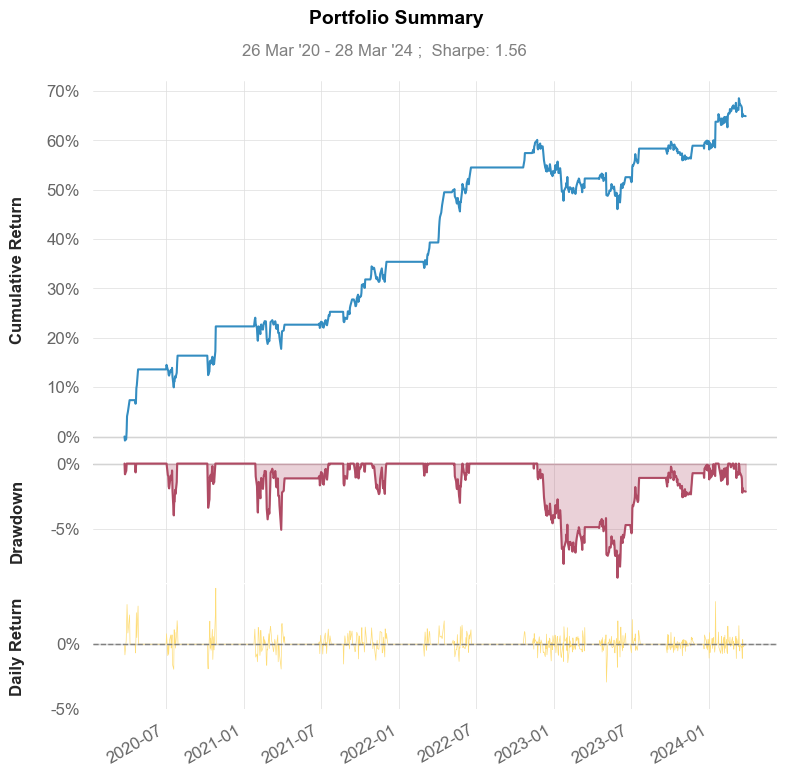

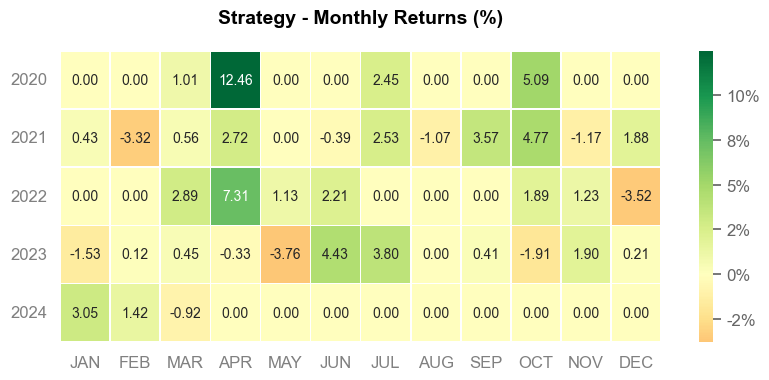

In [24]:
import quantstats as qs
qs.reports.basic(df['strategy_returns'])

In [25]:
qs.extend_pandas()

In [35]:
print("Strategy Sharpe Ratio:", round(qs.stats.sharpe(df['strategy_returns']), 2))
print("Strategy CAGR:", round(qs.stats.cagr(df['strategy_returns']),2))
print("Strategy Profit Factor:", round(qs.stats.profit_factor(df['strategy_returns']),2))
print("Strategy Returns Standard Deviation:", round(df['strategy_returns'].std(),4))

Strategy Sharpe Ratio: 1.52
Strategy CAGR: 0.08
Strategy Profit Factor: 1.49
Strategy Returns Standard Deviation: 0.0053


In [30]:
def leveraged_drawdown(strategy_returns, leverage):
    leveraged_returns = strategy_returns * leverage
    return qs.stats.max_drawdown(leveraged_returns)

# Calculate max drawdown for different leverage levels
max_drawdown_1x = leveraged_drawdown(df['strategy_returns'], 1)
max_drawdown_2x = leveraged_drawdown(df['strategy_returns'], 2)
max_drawdown_3x = leveraged_drawdown(df['strategy_returns'], 3)

# Print the max drawdowns
print("Max Drawdown for 1x leverage is:", round(max_drawdown_1x, 4))
print("Max Drawdown for 2x leverage is:", round(max_drawdown_2x, 4))
print("Max Drawdown for 3x leverage is:", round(max_drawdown_3x, 4))

Max Drawdown for 1x leverage is: -0.0877
Max Drawdown for 2x leverage is: -0.1714
Max Drawdown for 3x leverage is: -0.2509


In [31]:
def calculate_success_ratio(trades):
    successes = trades[trades > 0].count()
    total_trades = trades.count()
    return successes / total_trades

round(calculate_success_ratio(df['strategy_returns']),2)

0.25

In [32]:
qs.stats.monthly_returns(df['strategy_returns'])

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,EOY
2020,0.000000,0.000000,0.010080,0.124620,0.000000,0.000000,0.024513,0.000000,0.000000,0.050932,0.000000,0.000000,0.223077
2021,0.004307,-0.033233,0.005567,0.027160,0.000000,-0.003924,0.025319,-0.010683,0.035656,0.047704,-0.011746,0.018847,0.107023
2022,0.000000,0.000000,0.028900,0.073063,0.011277,0.022055,0.000000,0.000000,0.000000,0.018912,0.012327,-0.035230,0.135598
2023,-0.015267,0.001209,0.004530,-0.003313,-0.037616,0.044344,0.037992,0.000000,0.004142,-0.019087,0.018988,0.002121,0.035777
2024,0.030530,0.014175,-0.009212,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035510


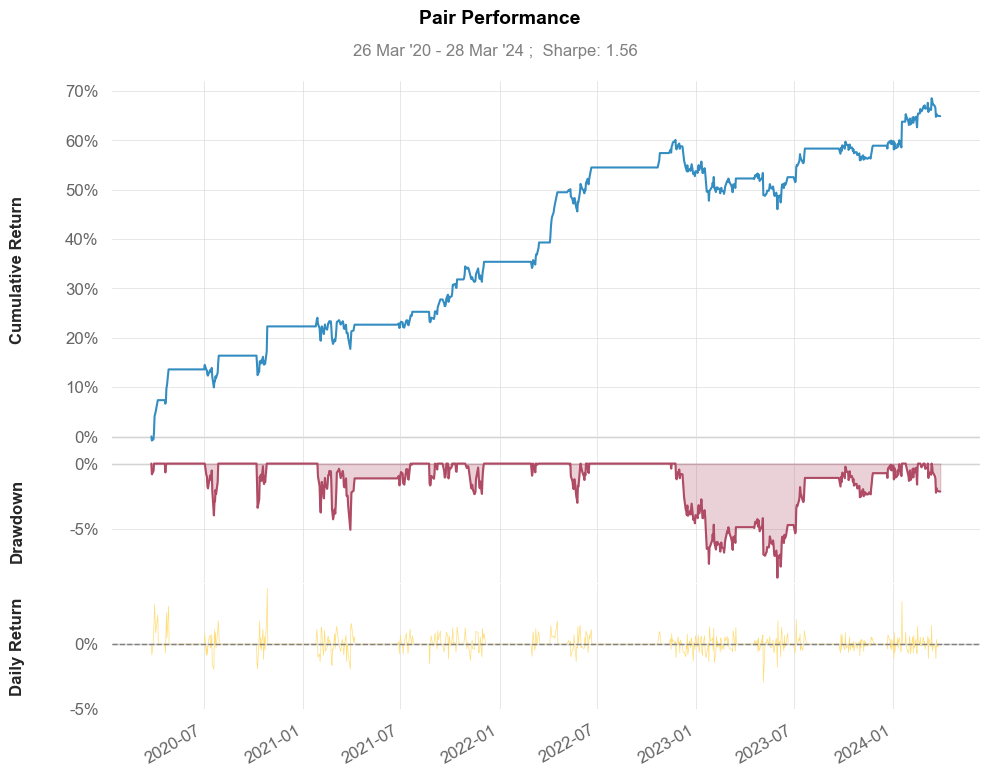

In [33]:
qs.plots.snapshot(df['strategy_returns'], title='Pair Performance', show=True)

# Define window size for the rolling ADF test
window_size = 90  # For example, 60 days

# Iterate over the data in daily intervals
for i in range(window_size, len(df)):
    # Select the window of data for this iteration
    window_data = df.iloc[i - window_size:i]
    
    # Perform the ADF test for the selected window of data
    #result = adfuller(window_data['Hdfc'] - window_data['Kotak'])
    result = adfuller(df.spread, maxlag = 1)
    
    # Check the p-value or test statistic
    adf_statistic = result[0]  # P-value is the second element of the result tuple
    
    # Print the result for this iteration
    print(f"Date: {df.index[i]}, ADF Test Statistic: {adf_statistic}")